In [8]:
import os
import urllib.request
import tarfile
import tempfile
import shutil

# Check if MPI is available (for when running as converted Python script)
try:
    import mpi4py.MPI as MPI
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    is_mpi = True
except ImportError:
    rank = 0
    is_mpi = False

# Download and extract 2D BP5 dataset (only on rank 0 if MPI is available)
if rank == 0:
    data_url = "https://github.com/guj/openPMD-example-datasets/raw/add_bp5_files/bp5/2d.tar.gz"
    data_dir = os.getcwd()
    dataset_2d_dir = os.path.join(data_dir, '2d')
    
    # Remove existing directory if it exists
    if os.path.exists(dataset_2d_dir):
        print(f"Removing existing dataset directory: {dataset_2d_dir}")
        shutil.rmtree(dataset_2d_dir)
    
    print(f"Downloading 2D BP5 dataset from {data_url}...")
    print(f"Extracting to {data_dir}...")
    
    # Create directory if it doesn't exist
    os.makedirs(data_dir, exist_ok=True)
    
    # Download to temporary file
    with tempfile.NamedTemporaryFile(delete=False, suffix='.tar.gz') as tmp_file:
        urllib.request.urlretrieve(data_url, tmp_file.name)
        
        # Extract tar.gz file - this will create a '2d' directory
        with tarfile.open(tmp_file.name, 'r:gz') as tar:
            tar.extractall(data_dir)
        
        # Clean up temporary file
        os.remove(tmp_file.name)
    
    print("Download and extraction complete!")

# Wait for rank 0 to finish download before other ranks proceed
if is_mpi:
    comm.Barrier()

# Set the data directory path for use in the notebook (all ranks need this)
data_dir = os.getcwd()
dataset_2d_dir = os.path.join(data_dir, '2d')
opmd_2d_dir = dataset_2d_dir
if rank == 0:
    print(f"Using data directory: {opmd_2d_dir}")

Removing existing dataset directory: /Users/dec2023/Work/2026/cursor/checked_in/2d
Extracting to /Users/dec2023/Work/2026/cursor/checked_in...
Download and extraction complete!
Using data directory: /Users/dec2023/Work/2026/cursor/checked_in/2d


In [9]:
import ipyparallel as ipp

# Create and start a cluster with 2 MPI engines
cluster = ipp.Cluster(engines="mpi", n=2)
rc = cluster.start_and_connect_sync()

# Activate the client to use all engines
rc.activate()
print(f"Connected to {len(rc.ids)} engines.")

Starting 2 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:06<00:00,  3.03s/engine]
Connected to 2 engines.


In [10]:
# Push the data directory path to all MPI engines
%px import os
%px import mpi4py.MPI as MPI
%px opmd_2d_dir = os.path.join(os.getcwd(), '2d')
%px opmd_2d_dir = os.path.abspath(opmd_2d_dir)
%px print(f"Rank {MPI.COMM_WORLD.Get_rank()}: Using data directory: {opmd_2d_dir}")

[stdout:1] Rank 1: Using data directory: /Users/dec2023/Work/2026/cursor/checked_in/2d


[stdout:0] Rank 0: Using data directory: /Users/dec2023/Work/2026/cursor/checked_in/2d


[stdout:1] Rank 1/2 running on host: JunminD023sMBP5.localdomain, PID: 79540


[stdout:0] ..... use MPI reader (size=2)
Rank 0/2 running on host: JunminD023sMBP5.localdomain, PID: 79539


[output:0]

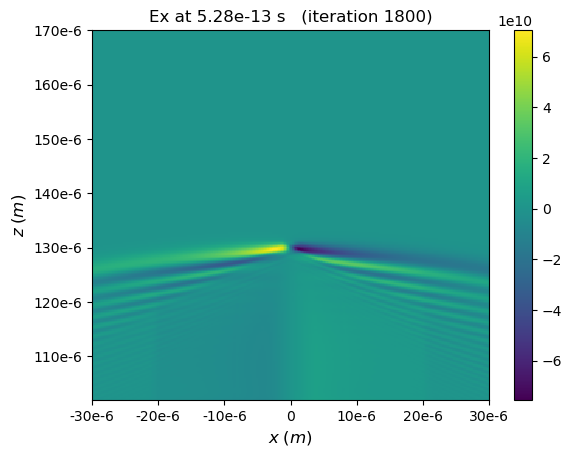

In [11]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries

# Use the opmd_2d_dir variable that was set in the previous cell
ts = OpenPMDTimeSeries(opmd_2d_dir)

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
host = os.uname().nodename

print(f"Rank {rank}/{size} running on host: {host}, PID: {os.getpid()}")
Ex, info_Ex = ts.get_field( iteration=1800, field='E', coord='x', plot=True ) 

[stdout:0] ..... use MPI reader (size=2)


[output:0]

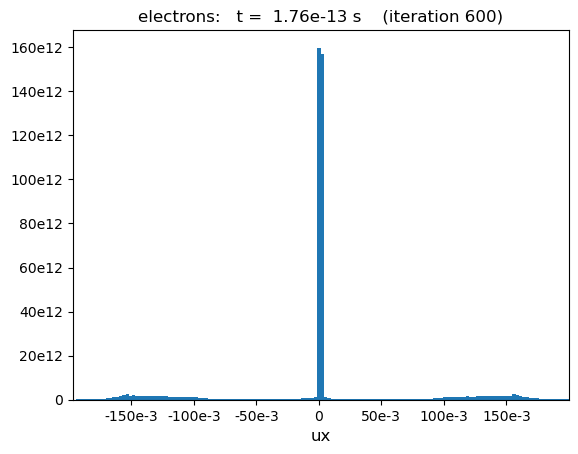

In [12]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries

# Use the opmd_2d_dir variable that was set in the previous cell
ts = OpenPMDTimeSeries(opmd_2d_dir)

ux = ts.get_particle( var_list=['ux'], iteration=600, species='electrons', plot=True )

[stdout:0] ..... use MPI reader (size=2)


[output:0]

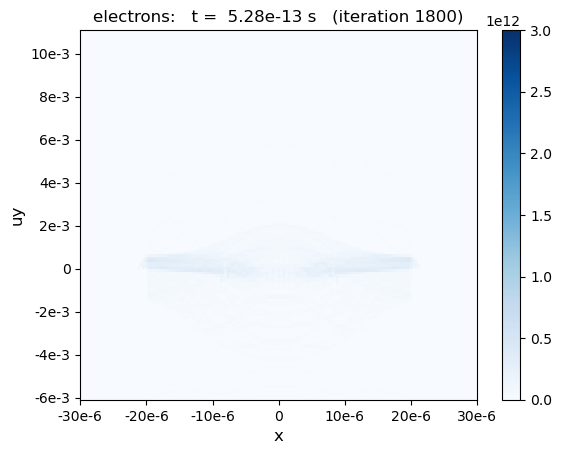

In [13]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries

# Use the opmd_2d_dir variable that was set in the previous cell
ts = OpenPMDTimeSeries(opmd_2d_dir)

x, uy = ts.get_particle( var_list=['x','uy'], iteration=1800, species='electrons', plot=True, vmax=3e12 )

[stdout:0] ..... use MPI reader (size=2)


[output:0]

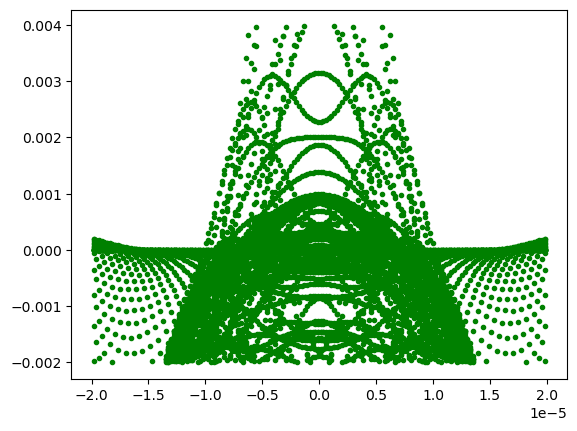

In [14]:
%%px
%matplotlib inline
import mpi4py.MPI as MPI
import os
import matplotlib.pyplot as plt
import numpy as np

from openpmd_viewer import OpenPMDTimeSeries

# Use the opmd_2d_dir variable that was set in the previous cell
ts = OpenPMDTimeSeries(opmd_2d_dir)

x_selected, uy_selected = ts.get_particle( ['x', 'uy'], species='electrons', 
                            iteration=300, select={'uy':[-0.002, 0.004]} )
if (rank == 0):
    plt.plot(x_selected, uy_selected, 'g.')